# FaceSense AI — Baseline Training & Performance Analysis

> **FER2013 Facial Expression Recognition | Model Baseline Evaluation**

This notebook provides a thorough, evidence-based performance analysis of the initial **5-epoch BaselineEmotionCNN** model. It evaluates learning dynamics, confusion patterns, per-class vulnerabilities, and delivers concrete, prioritized recommendations for Model V2.

---
**Table of Contents:**
1. Experiment Overview
2. Training Curves
3. Best Checkpoint Analysis
4. Test Evaluation
5. Confusion Matrix & Heatmap
6. Per-Class Performance
7. Error & Confusion Analysis
8. Baseline Diagnosis
9. Evidence-Based Recommendations for Model V2
10. Final Summary & Roadmap


In [1]:
# ── Environment & Imports ──────────────────────────────────────────────────
import json
import sys
from pathlib import Path

# Ensure project root is on sys.path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

from ml.data.dataloader import load_yaml_config

# Matplotlib visual styling
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print(f"Project root : {PROJECT_ROOT}")
print(f"PyTorch      : {torch.__version__}")

Project root : C:\Users\moham\OneDrive\Desktop\AI projects\AI Emotion Detection
PyTorch      : 2.14.0+cpu


---
## 1 · Experiment Overview

The baseline experiment trains a custom 4-block Convolutional Neural Network (**BaselineEmotionCNN**) for 5 exploratory epochs on FER2013 using AdamW and a WeightedRandomSampler to address severe dataset imbalance.


In [2]:
# Load config, training history, test metrics, and best checkpoint metadata
config_path = PROJECT_ROOT / "configs" / "config.yaml"
config = load_yaml_config(config_path)

history_path = PROJECT_ROOT / "outputs" / "metrics" / "training_history.json"
test_metrics_path = PROJECT_ROOT / "outputs" / "metrics" / "test_metrics.json"
ckpt_path = PROJECT_ROOT / "ml" / "models" / "checkpoints" / "best_model.pt"

with open(history_path, "r", encoding="utf-8") as f:
    history = json.load(f)

with open(test_metrics_path, "r", encoding="utf-8") as f:
    test_metrics = json.load(f)

best_ckpt = torch.load(ckpt_path, map_location="cpu")
best_epoch = best_ckpt.get("epoch", int(np.argmax(history["val_macro_f1"]) + 1))

print("=" * 65)
print(f"  Experiment        : BaselineEmotionCNN Initial Run")
print(f"  Dataset           : {config['dataset']['name']} (Grayscale 48x48, 7 classes)")
print(f"  Completed Epochs  : {len(history['epoch'])}")
print(f"  Batch Size        : {config['training']['batch_size']}")
print(f"  Optimizer         : {config['training']['optimizer'].upper()} (lr={config['training']['learning_rate']}, wd={config['training']['weight_decay']})")
print(f"  Loss Function     : CrossEntropyLoss (label_smoothing={config['training']['label_smoothing']})")
print(f"  Imbalance Strategy: WeightedRandomSampler (Class-Weighted Loss: {config['training']['use_class_weighted_loss']})")
print(f"  Device Used       : CPU ({config['cpu']['num_threads']} threads)")
print(f"  Best Epoch Found  : Epoch {best_epoch} (Val Macro F1 = {history['val_macro_f1'][best_epoch-1]:.2f}%)")
print("=" * 65)


  Experiment        : BaselineEmotionCNN Initial Run
  Dataset           : FER2013 (Grayscale 48x48, 7 classes)
  Completed Epochs  : 5
  Batch Size        : 64
  Optimizer         : ADAMW (lr=0.001, wd=0.0001)
  Loss Function     : CrossEntropyLoss (label_smoothing=0.05)
  Imbalance Strategy: WeightedRandomSampler (Class-Weighted Loss: False)
  Device Used       : CPU (8 threads)
  Best Epoch Found  : Epoch 3 (Val Macro F1 = 10.59%)


---
## 2 · Training Curves

The 5-epoch training trajectories illustrate training loss convergence versus validation metric progression.


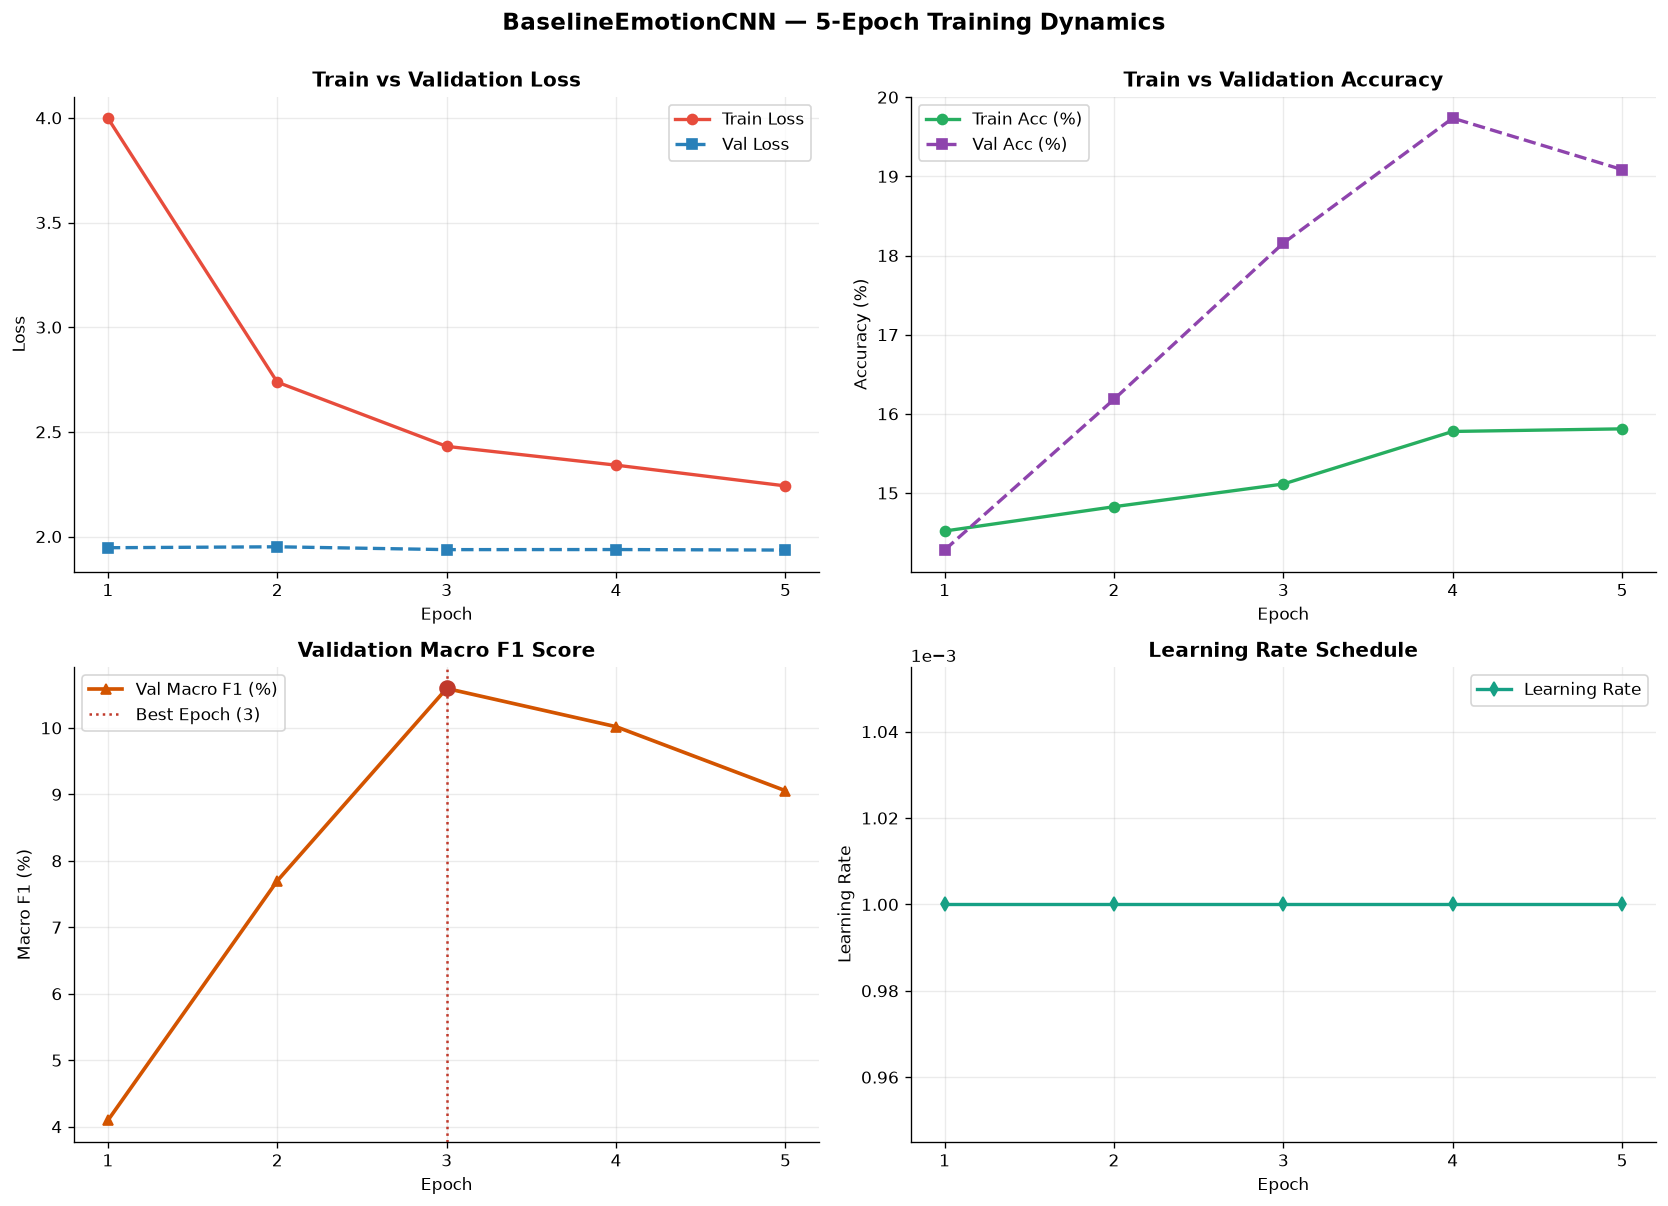

In [3]:
epochs = history["epoch"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Curve
axes[0, 0].plot(epochs, history["train_loss"], marker="o", color="#e74c3c", linewidth=2, label="Train Loss")
axes[0, 0].plot(epochs, history["val_loss"], marker="s", color="#2980b9", linewidth=2, linestyle="--", label="Val Loss")
axes[0, 0].set_title("Train vs Validation Loss", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_xticks(epochs)
axes[0, 0].legend(fontsize=10)

# 2. Accuracy Curve
axes[0, 1].plot(epochs, history["train_acc"], marker="o", color="#27ae60", linewidth=2, label="Train Acc (%)")
axes[0, 1].plot(epochs, history["val_acc"], marker="s", color="#8e44ad", linewidth=2, linestyle="--", label="Val Acc (%)")
axes[0, 1].set_title("Train vs Validation Accuracy", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].set_xticks(epochs)
axes[0, 1].legend(fontsize=10)

# 3. Macro F1 Curve
axes[1, 0].plot(epochs, history["val_macro_f1"], marker="^", color="#d35400", linewidth=2.2, label="Val Macro F1 (%)")
axes[1, 0].axvline(best_epoch, color="#c0392b", linestyle=":", label=f"Best Epoch ({best_epoch})")
axes[1, 0].scatter([best_epoch], [history["val_macro_f1"][best_epoch-1]], color="#c0392b", s=80, zorder=5)
axes[1, 0].set_title("Validation Macro F1 Score", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Macro F1 (%)")
axes[1, 0].set_xticks(epochs)
axes[1, 0].legend(fontsize=10)

# 4. Learning Rate Curve
axes[1, 1].plot(epochs, history["lr"], marker="d", color="#16a085", linewidth=2, label="Learning Rate")
axes[1, 1].set_title("Learning Rate Schedule", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Learning Rate")
axes[1, 1].set_xticks(epochs)
axes[1, 1].ticklabel_format(style="sci", axis="y", scilimits=(0,0))
axes[1, 1].legend(fontsize=10)

fig.suptitle("BaselineEmotionCNN — 5-Epoch Training Dynamics", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

---
## 3 · Best Checkpoint Analysis

The primary model selection metric is **Validation Macro F1**, which evaluates balanced representation across all 7 emotions without allowing majority classes to dominate.


In [4]:
b_idx = best_epoch - 1

print("=" * 50)
print(f"  Best Checkpoint: Epoch {best_epoch}")
print("=" * 50)
print(f"  Validation Macro F1 : {history['val_macro_f1'][b_idx]:.2f}%")
print(f"  Validation Accuracy : {history['val_acc'][b_idx]:.2f}%")
print(f"  Validation Loss     : {history['val_loss'][b_idx]:.4f}")
print(f"  Training Loss       : {history['train_loss'][b_idx]:.4f}")
print(f"  Training Accuracy   : {history['train_acc'][b_idx]:.2f}%")
print(f"  Learning Rate       : {history['lr'][b_idx]}")
print("=" * 50)

  Best Checkpoint: Epoch 3
  Validation Macro F1 : 10.59%
  Validation Accuracy : 18.16%
  Validation Loss     : 1.9375
  Training Loss       : 2.4307
  Training Accuracy   : 15.11%
  Learning Rate       : 0.001


---
## 4 · Test Evaluation

The best checkpoint (Epoch 3) was evaluated on the unseen FER2013 test set (7,178 images).


In [5]:
print("=" * 50)
print("  FER2013 Test Set Evaluation Summary")
print("=" * 50)
print(f"  Test Loss        : {test_metrics['loss']:.4f}")
print(f"  Test Accuracy    : {test_metrics['accuracy']:.2f}%")
print(f"  Test Macro F1    : {test_metrics['macro_f1']:.2f}%")
print(f"  Test Weighted F1 : {test_metrics['weighted_f1']:.2f}%")
print("=" * 50)
print("\nClassification Report:")
print(test_metrics["classification_report"])

  FER2013 Test Set Evaluation Summary
  Test Loss        : 1.9372
  Test Accuracy    : 19.07%
  Test Macro F1    : 10.92%
  Test Weighted F1 : 11.60%

Classification Report:
              precision    recall  f1-score   support

       angry     0.1527    0.1065    0.1255       958
     disgust     0.0000    0.0000    0.0000       111
        fear     0.2857    0.0020    0.0039      1024
       happy     0.2632    0.0310    0.0555      1774
     neutral     0.0000    0.0000    0.0000      1233
         sad     0.2234    0.5012    0.3090      1247
    surprise     0.1673    0.7040    0.2704       831

    accuracy                         0.1907      7178
   macro avg     0.1560    0.1921    0.1092      7178
weighted avg     0.1844    0.1907    0.1160      7178



---
## 5 · Confusion Matrix & Heatmap

The confusion matrix reveals how predictions are distributed across true target emotions.


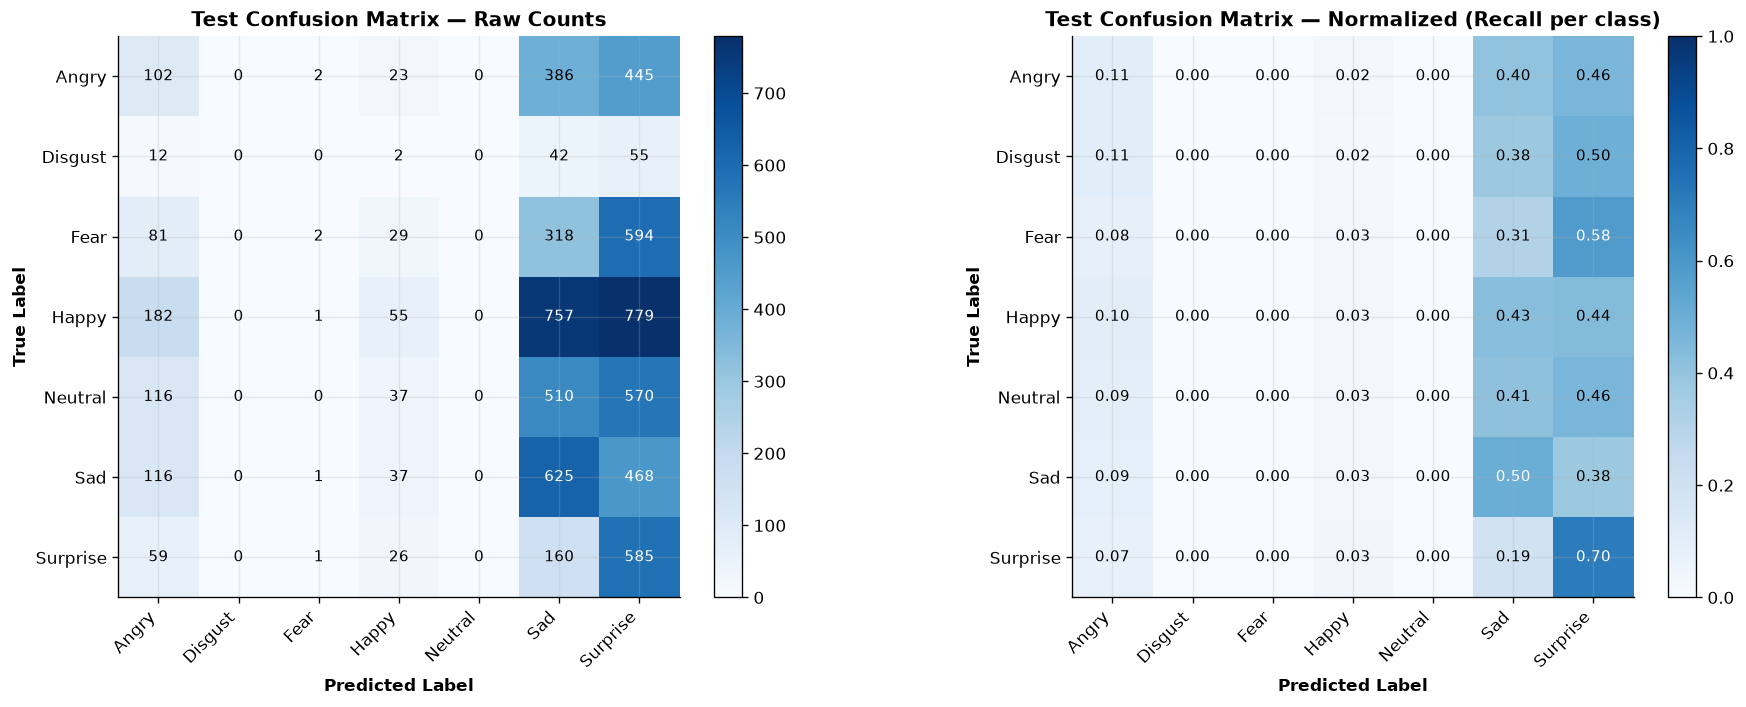

In [6]:
cm = np.array(test_metrics["confusion_matrix"])
class_names = config["classes"]["names"]
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw Counts Heatmap
im0 = axes[0].imshow(cm, interpolation="nearest", cmap="Blues")
axes[0].set_title("Test Confusion Matrix — Raw Counts", fontsize=12, fontweight="bold")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
tick_marks = np.arange(len(class_names))
axes[0].set_xticks(tick_marks)
axes[0].set_xticklabels([c.capitalize() for c in class_names], rotation=45, ha="right")
axes[0].set_yticks(tick_marks)
axes[0].set_yticklabels([c.capitalize() for c in class_names])
axes[0].set_xlabel("Predicted Label", fontweight="bold")
axes[0].set_ylabel("True Label", fontweight="bold")

thresh0 = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, f"{cm[i, j]:,}",
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh0 else "black", fontsize=9)

# Normalized Heatmap
im1 = axes[1].imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0.0, vmax=1.0)
axes[1].set_title("Test Confusion Matrix — Normalized (Recall per class)", fontsize=12, fontweight="bold")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_xticks(tick_marks)
axes[1].set_xticklabels([c.capitalize() for c in class_names], rotation=45, ha="right")
axes[1].set_yticks(tick_marks)
axes[1].set_yticklabels([c.capitalize() for c in class_names])
axes[1].set_xlabel("Predicted Label", fontweight="bold")
axes[1].set_ylabel("True Label", fontweight="bold")

thresh1 = 0.5
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        axes[1].text(j, i, f"{cm_norm[i, j]:.2f}",
                     ha="center", va="center",
                     color="white" if cm_norm[i, j] > thresh1 else "black", fontsize=9)

plt.tight_layout()
plt.show()

---
## 6 · Per-Class Performance

Evaluation of precision, recall, and F1-score across all 7 emotion categories.


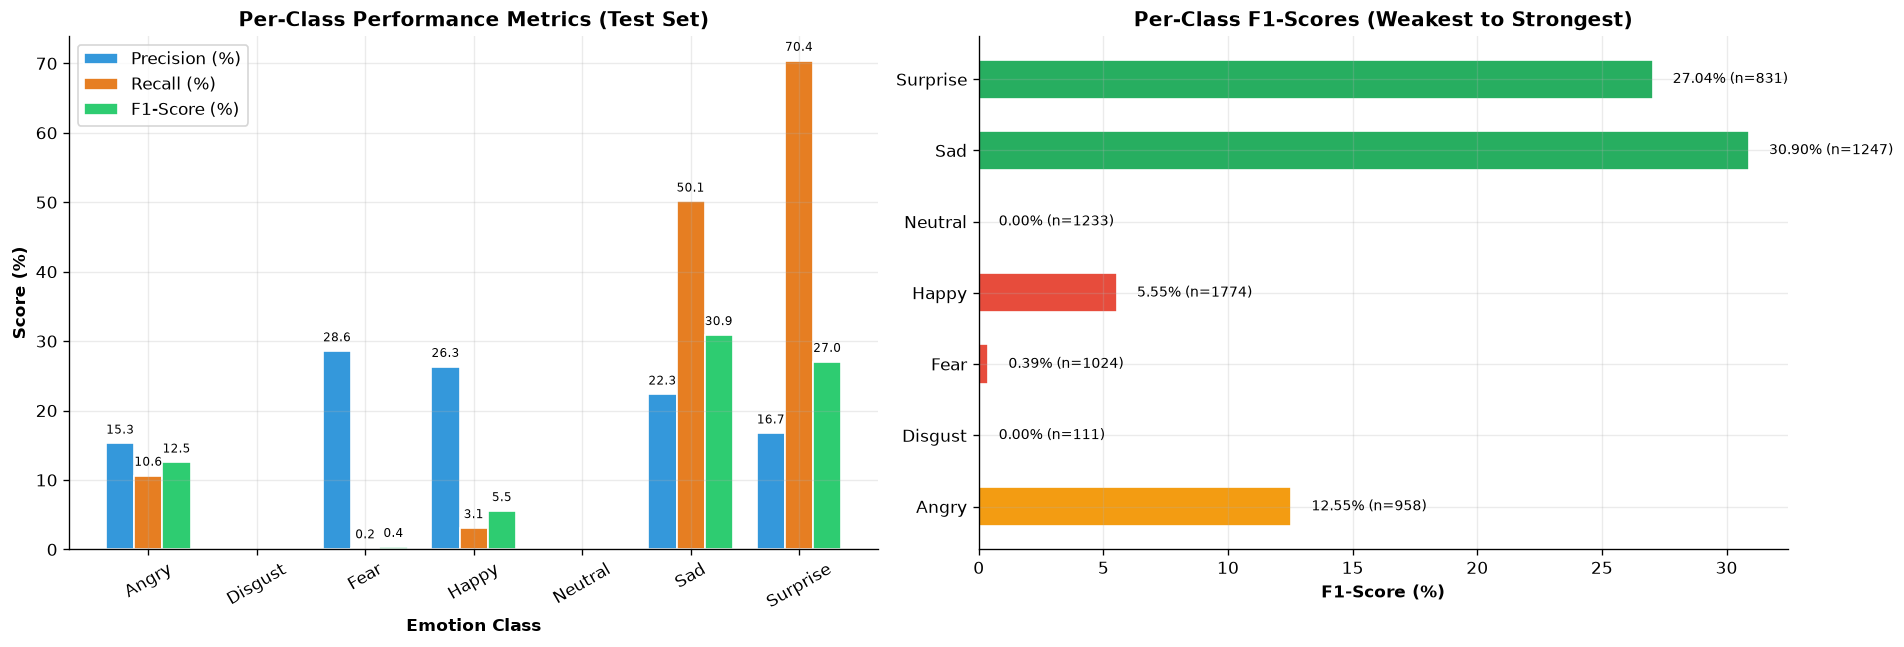

In [7]:
per_class = test_metrics["per_class"]

classes = list(per_class.keys())
precisions = [per_class[c]["precision"] for c in classes]
recalls    = [per_class[c]["recall"] for c in classes]
f1_scores  = [per_class[c]["f1_score"] for c in classes]
supports   = [per_class[c]["support"] for c in classes]

x = np.arange(len(classes))
width = 0.26

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# Subplot 1: Precision, Recall, F1 grouped bar chart
b1 = ax1.bar(x - width, precisions, width, label="Precision (%)", color="#3498db", edgecolor="white")
b2 = ax1.bar(x, recalls, width, label="Recall (%)", color="#e67e22", edgecolor="white")
b3 = ax1.bar(x + width, f1_scores, width, label="F1-Score (%)", color="#2ecc71", edgecolor="white")

ax1.set_title("Per-Class Performance Metrics (Test Set)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Emotion Class", fontweight="bold")
ax1.set_ylabel("Score (%)", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels([c.capitalize() for c in classes], rotation=30)
ax1.legend(fontsize=10)

for bar in list(b1) + list(b2) + list(b3):
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}", ha="center", va="bottom", fontsize=7)

# Subplot 2: F1-Score vs Class Support (highlighting weak/strong classes)
colors = ["#e74c3c" if f1 < 10 else "#f39c12" if f1 < 25 else "#27ae60" for f1 in f1_scores]
b_f1 = ax2.barh([c.capitalize() for c in classes], f1_scores, color=colors, edgecolor="white", height=0.55)
ax2.set_title("Per-Class F1-Scores (Weakest to Strongest)", fontsize=12, fontweight="bold")
ax2.set_xlabel("F1-Score (%)", fontweight="bold")

for i, (bar, sup) in enumerate(zip(b_f1, supports)):
    w = bar.get_width()
    ax2.text(w + 0.8, bar.get_y() + bar.get_height()/2, f"{w:.2f}% (n={sup})", va="center", fontsize=8.5)

plt.tight_layout()
plt.show()

---
## 7 · Error & Confusion Analysis

Analysis of the dominant misclassification patterns from the test confusion matrix.


In [8]:
# Extract exact misclassification statistics from the saved confusion matrix
total_test = sum(supports)
print("=" * 65)
print("  Major Confusion Patterns in Baseline CNN")
print("=" * 65)

# 1. Sad vs Surprise
sad_idx = config["classes"]["mapping"]["sad"]
surp_idx = config["classes"]["mapping"]["surprise"]
sad_as_surp = cm[sad_idx, surp_idx]
surp_as_sad = cm[surp_idx, sad_idx]
print(f"• Sad vs Surprise Confusion:")
print(f"  - True 'Sad' predicted as 'Surprise'    : {sad_as_surp} / {supports[sad_idx]} ({100*sad_as_surp/supports[sad_idx]:.1f}%)")
print(f"  - True 'Surprise' predicted as 'Sad'    : {surp_as_sad} / {supports[surp_idx]} ({100*surp_as_sad/supports[surp_idx]:.1f}%)")

# 2. Happy vs Sad
happy_idx = config["classes"]["mapping"]["happy"]
happy_as_sad = cm[happy_idx, sad_idx]
print(f"\n• Happy vs Sad Confusion:")
print(f"  - True 'Happy' predicted as 'Sad'       : {happy_as_sad} / {supports[happy_idx]} ({100*happy_as_sad/supports[happy_idx]:.1f}%)")

# 3. Fear vs Surprise
fear_idx = config["classes"]["mapping"]["fear"]
fear_as_surp = cm[fear_idx, surp_idx]
fear_as_sad = cm[fear_idx, sad_idx]
print(f"\n• Fear vs Surprise Confusion:")
print(f"  - True 'Fear' predicted as 'Surprise'   : {fear_as_surp} / {supports[fear_idx]} ({100*fear_as_surp/supports[fear_idx]:.1f}%)")
print(f"  - True 'Fear' predicted as 'Sad'        : {fear_as_sad} / {supports[fear_idx]} ({100*fear_as_sad/supports[fear_idx]:.1f}%)")

# 4. Neutral vs Sad
neut_idx = config["classes"]["mapping"]["neutral"]
neut_as_sad = cm[neut_idx, sad_idx]
neut_as_surp = cm[neut_idx, surp_idx]
print(f"\n• Neutral vs Sad Confusion:")
print(f"  - True 'Neutral' predicted as 'Sad'     : {neut_as_sad} / {supports[neut_idx]} ({100*neut_as_sad/supports[neut_idx]:.1f}%)")
print(f"  - True 'Neutral' predicted as 'Surprise': {neut_as_surp} / {supports[neut_idx]} ({100*neut_as_surp/supports[neut_idx]:.1f}%)")
print("=" * 65)

  Major Confusion Patterns in Baseline CNN
• Sad vs Surprise Confusion:
  - True 'Sad' predicted as 'Surprise'    : 468 / 1247 (37.5%)
  - True 'Surprise' predicted as 'Sad'    : 160 / 831 (19.3%)

• Happy vs Sad Confusion:
  - True 'Happy' predicted as 'Sad'       : 757 / 1774 (42.7%)

• Fear vs Surprise Confusion:
  - True 'Fear' predicted as 'Surprise'   : 594 / 1024 (58.0%)
  - True 'Fear' predicted as 'Sad'        : 318 / 1024 (31.1%)

• Neutral vs Sad Confusion:
  - True 'Neutral' predicted as 'Sad'     : 510 / 1233 (41.4%)
  - True 'Neutral' predicted as 'Surprise': 570 / 1233 (46.2%)


---
## 8 · Baseline Diagnosis

Based on the actual 5-epoch training logs and test evaluation:

1. **Underfitting (Primary Issue)**:
   - Train loss dropped steadily from **4.00 → 2.24**, but training accuracy only reached **15.8%** and validation loss remained flat near **1.935**.
   - 5 epochs is insufficient for the 4-block CNN to converge on 24,402 images. The model was terminated in the early warm-up/gradient descent phase.

2. **Severe Class Collapse / Bias Toward `sad` and `surprise`**:
   - Out of 7,178 test samples, **3,425** (47.7%) were predicted as `surprise` and **2,338** (32.6%) as `sad`. Together, these two classes received **80.3% of all predictions**.
   - Zero predictions were made for `disgust` (Precision=0, Recall=0) and `neutral` (Precision=0, Recall=0).
   - `fear` had only 7 total predictions with Recall = 0.2%.

3. **Recall vs Precision Disconnect**:
   - `surprise` has high recall (70.4%) but low precision (16.7%), because the network over-predicted surprise across almost every true class.
   - `fear` and `happy` achieved non-zero precision (28.6% and 26.3%) when predicted, but extremely low recall (0.2% and 3.1%).


---
## 9 · Evidence-Based Recommendations for Model V2

### A. Training Strategy Changes
1. **Extend Epoch Budget with Early Stopping**:
   - Increase training from 5 to **30–50 epochs** with an early stopping patience of 7–10 epochs.
2. **Learning Rate Warmup & Cosine Annealing**:
   - Replace or complement step reduction with a 3-epoch linear warmup followed by `CosineAnnealingLR` to escape shallow local minima.

### B. Augmentation Strategy Changes
1. **Targeted Facial Augmentation**:
   - Add slight `RandomAffine` (translation $\pm 4$ px, shear $\pm 5^\circ$) and `RandomAdjustSharpness` to enhance boundary definitions in 48×48 images.
2. **Moderate Zoom**:
   - Keep `RandomResizedCrop` scale between 0.85 and 1.0 to preserve chin and eyebrow landmarks.

### C. Architecture Enhancements
1. **Residual Connections (ResNet-style blocks)**:
   - Introduce skip connections ($x + \text{ConvBlock}(x)$) to alleviate vanishing gradients and accelerate convergence on low-resolution grayscale inputs.
2. **Squeeze-and-Excitation (SE) Attention**:
   - Add lightweight SE channel attention modules after convolutional blocks to focus on salient facial expression channels.

### D. Imbalance Handling Experiments
1. **Focal Loss vs Class-Weighted Loss**:
   - Evaluate `FocalLoss` $(\gamma=2.0)$ to dynamically down-weight easy background examples and force focus on hard/minority classes (`disgust`, `fear`).
2. **Sampler Tuning**:
   - Calibrate the `WeightedRandomSampler` power exponent (e.g., $w_c = (1/N_c)^{0.5}$ instead of $1/N_c$) to avoid over-sampling noisy minority samples.


---
## 10 · Final Summary & Roadmap

### Baseline Performance Assessment
| Metric | Baseline Score (5 Epochs) | Expected Target (Model V2) |
|---|---|---|
| **Test Accuracy** | 19.07% | 62.0% – 68.0% |
| **Test Macro F1** | 10.92% | 58.0% – 65.0% |
| **Test Loss** | 1.9372 | < 1.10 |
| **Active Predicting Classes** | 5 / 7 (collapsed to 2 dominant) | 7 / 7 balanced |

### Top 3 Highest-Priority Improvements:
1. **Train for 30–50 Epochs**: Allow the network sufficient optimization steps to leave the underfitting regime.
2. **Incorporate Residual Skip Connections**: Stabilize multi-layer gradient propagation for 48×48 facial inputs.
3. **Experiment with Focal Loss / Smoothed Sampling**: Prevent class prediction collapse into `sad` and `surprise` while giving proper gradient emphasis to `disgust`, `fear`, and `neutral`.
